# Controlled Descent Simulator — Quadrotor Model for Nonlinear MPC (iLQR)

This notebook derives the **prediction model** used by a nonlinear Model-Predictive
Controller for the quadrotor. It is the MPC counterpart of the FF+LQR derivation
in `dynamics_quadRotor_FFLQR01.ipynb`, and it deliberately reuses the *same*
6-DOF plant so the two controllers are compared on equal footing.

**What an MPC needs from a model.** An MPC does not use a fixed control law.
At every control instant it *predicts* how the vehicle will move over a short
horizon of `N` steps under a candidate sequence of motor commands, scores those
predictions against a reference, and picks the sequence that minimises the score
subject to the actuator limits — then applies only the first command and repeats.
So the model has to be a **prediction machine**:

$$x_{k+1} = F_d(x_k,\,u_k),\qquad k = 0,\dots,N-1,$$

together with its **sensitivities**

$$A_k = \frac{\partial F_d}{\partial x}\Big|_{x_k,u_k},\qquad
  B_k = \frac{\partial F_d}{\partial u}\Big|_{x_k,u_k}.$$

**Why the Jacobians.** The solver we chose — *iterative LQR / control-limited
DDP* — is exactly what its name says: it linearises the nonlinear rollout around
the current guess and solves an LQR-like sub-problem (a backward Riccati-style
recursion) to improve it, iterating to convergence. That backward pass consumes
`A_k` and `B_k` at every knot. This is the one structural difference from the
LQR notebook: LQR linearises **once**, at hover, and ships a constant gain;
MPC re-linearises the **actual predicted trajectory** on every tick.

**This step builds only the model** — the discrete map `F_d` and its Jacobians,
validated numerically. The cost function, the horizon, and the backward/forward
passes come in the following steps.

In [48]:
import sympy as sp
from sympy import symbols, Matrix, sqrt, Rational, diag
sp.init_printing(use_latex='mathjax', wrap_line=False)

import numpy as np

print("SymPy:", sp.__version__)
print("NumPy:", np.__version__)

SymPy: 1.14.0
NumPy: 2.4.4


## 1. Continuous nonlinear 6-DOF model

We take the **same plant** as the LQR derivation: a rigid body with a unit
quaternion for attitude, world-frame translational dynamics, body-frame Euler
rotational dynamics, and a body-attached linear drag. The state is 13-dimensional

$$x = [\;r_{x,y,z},\; q_{w,x,y,z},\; v_{x,y,z},\; \omega_{x,y,z}\;]^\top .$$

**The control is the four motor thrusts** $u = [T_1,T_2,T_3,T_4]^\top$, *not* the
virtual wrench $[F,\tau]$. This is a deliberate MPC modelling choice: the physical
limits of the vehicle are per-rotor thrust bounds $T_i\in[T_\mathrm{min},T_\mathrm{max}]$, and by
optimising directly over $T_i$ those limits become a simple **box constraint** —
which control-limited DDP handles natively in its backward pass. (LQR did the
opposite: it computed a wrench, then inverted the allocation matrix and clamped.)

In [49]:
# ---- symbolic parameters (same airframe as the LQR notebook) ----
m, Ixx, Iyy, Izz, g = symbols('m I_xx I_yy I_zz g', positive=True)
d_x, d_y, d_z       = symbols('d_x d_y d_z', positive=True)      # world/body linear-drag diag
k_T, k_Q, I_rot     = symbols('k_T k_Q I_rot', positive=True)    # thrust/torque coeffs, rotor inertia
L                   = symbols('L', positive=True)                # arm length (centre -> motor)

# ---- state variables ----
r_x, r_y, r_z       = symbols('r_x r_y r_z', real=True)
q_w, q_x, q_y, q_z  = symbols('q_w q_x q_y q_z', real=True)
v_x, v_y, v_z       = symbols('v_x v_y v_z', real=True)
w_x, w_y, w_z       = symbols('w_x w_y w_z', real=True)          # body rates omega

# ---- control inputs: the four motor thrusts ----
T1, T2, T3, T4      = symbols('T1 T2 T3 T4', real=True)

q_vec = Matrix([q_w, q_x, q_y, q_z])
w_vec = Matrix([w_x, w_y, w_z])
v_vec = Matrix([v_x, v_y, v_z])
Imat  = diag(Ixx, Iyy, Izz)

### 1.1 Rotation matrix and attitude kinematics

The body-to-world rotation from the quaternion, and the quaternion derivative
$\dot q = \tfrac12\,\Omega(\omega)\,q$. The unit-norm constraint $\|q\|=1$ is a
manifold that ordinary integration does not preserve exactly — we deal with it in
§3 by renormalising after each step.

In [50]:
def R_of_q(qw, qx, qy, qz):
    return Matrix([
        [1-2*(qy**2+qz**2), 2*(qx*qy-qw*qz),   2*(qx*qz+qw*qy)],
        [2*(qx*qy+qw*qz),   1-2*(qx**2+qz**2), 2*(qy*qz-qw*qx)],
        [2*(qx*qz-qw*qy),   2*(qy*qz+qw*qx),   1-2*(qx**2+qy**2)],
    ])

R = R_of_q(q_w, q_x, q_y, q_z)

Omega = Matrix([
    [0,   -w_x, -w_y, -w_z],
    [w_x,  0,    w_z, -w_y],
    [w_y, -w_z,  0,    w_x],
    [w_z,  w_y, -w_x,  0  ],
])
q_dot = Rational(1, 2) * Omega * q_vec
q_dot

⎡  qₓ⋅wₓ   q_y⋅w_y   q_z⋅w_z⎤
⎢- ───── - ─────── - ───────⎥
⎢    2        2         2   ⎥
⎢                           ⎥
⎢q_w⋅wₓ   q_y⋅w_z   q_z⋅w_y ⎥
⎢────── + ─────── - ─────── ⎥
⎢  2         2         2    ⎥
⎢                           ⎥
⎢ q_w⋅w_y   qₓ⋅w_z   q_z⋅wₓ ⎥
⎢ ─────── - ────── + ────── ⎥
⎢    2        2        2    ⎥
⎢                           ⎥
⎢ q_w⋅w_z   qₓ⋅w_y   q_y⋅wₓ ⎥
⎢ ─────── + ────── - ────── ⎥
⎣    2        2        2    ⎦

### 1.2 Control allocation — from motor thrusts to the wrench

The four thrusts produce a collective force $F$ and a body torque $\tau$ through
the fixed **ArduPilot QuadX** allocation matrix $M$ (identical to §2 of the LQR
notebook). Because $u = T$, the wrench is simply the affine map $[F,\tau]^\top =
M\,T$, and we substitute it into the dynamics — the allocation lives *inside* the
model instead of being inverted afterwards.

In [51]:
d   = L / sqrt(2)          # motor x,y offset on the 45-degree X
c_r = k_Q / k_T            # torque-to-thrust ratio

#              M1(FR)   M2(RL)   M3(FL)   M4(RR)
pos = [( d, -d), (-d,  d), ( d,  d), (-d, -d)]
sig = [   +1,      +1,      -1,      -1    ]      # +1 = CCW, -1 = CW

M_alloc = Matrix([
    [1, 1, 1, 1],
    [ pos[0][1],  pos[1][1],  pos[2][1],  pos[3][1]],      # tau_x =  sum T*y
    [-pos[0][0], -pos[1][0], -pos[2][0], -pos[3][0]],      # tau_y = -sum T*x
    [-sig[0]*c_r, -sig[1]*c_r, -sig[2]*c_r, -sig[3]*c_r],  # tau_z =  sum -sigma*c*T
])
wrench = M_alloc * Matrix([T1, T2, T3, T4])
F, tau_x, tau_y, tau_z = wrench
M_alloc

⎡  1       1      1       1   ⎤
⎢                             ⎥
⎢-√2⋅L   √2⋅L    √2⋅L   -√2⋅L ⎥
⎢──────  ────    ────   ──────⎥
⎢  2      2       2       2   ⎥
⎢                             ⎥
⎢-√2⋅L   √2⋅L   -√2⋅L    √2⋅L ⎥
⎢──────  ────   ──────   ──── ⎥
⎢  2      2       2       2   ⎥
⎢                             ⎥
⎢-k_Q    -k_Q    k_Q     k_Q  ⎥
⎢─────   ─────   ───     ───  ⎥
⎣ k_T     k_T    k_T     k_T  ⎦

### 1.3 Translational and rotational dynamics

Translational (world frame): thrust rotated into the world, gravity, and a
body-attached linear drag $-R\,D\,R^\top v$. Rotational (body frame): the Euler
equation $I\dot\omega = \tau - \omega\times I\omega$.

**One deliberate simplification vs the plant:** we drop the residual rotor
gyroscopic term $\omega\times[0,0,I_\text{rot}S]^\top$. At a symmetric hover the
signed spin sum $S=\sum_i \sigma_i\sqrt{T_i/k_T}$ is $\approx 0$, and — crucially
for MPC — its $\sqrt{T_i}$ dependence has an **unbounded derivative at
$T_i=0=T_\mathrm{min}$**, which would make $B_k$ singular exactly on the constraint
boundary. Neglecting a tiny, non-smooth term buys well-conditioned Jacobians
across the whole feasible box. It can be reinstated later as a smoothed term if
its effect proves non-negligible.

In [52]:
D_mat        = diag(d_x, d_y, d_z)
thrust_world = R * Matrix([0, 0, F])
gravity      = Matrix([0, 0, -m*g])
v_body       = R.T * v_vec
drag_world   = R * (-D_mat * v_body)
v_dot        = (thrust_world + gravity + drag_world) / m

tau_vec = Matrix([tau_x, tau_y, tau_z])
w_dot   = Imat.inv() * (tau_vec - w_vec.cross(Imat * w_vec))   # rotor gyro neglected (see above)
v_dot, w_dot

⎛                                                                                                                                                                                                                                                                                                                                                                                                                   ⎡                              √2⋅L⋅T₁   √2⋅L⋅T₂   √2⋅L⋅T₃   √2⋅L⋅T₄⎤⎞
⎜⎡       ⎛       2        2    ⎞ ⎛   ⎛       2        2    ⎞                                                           ⎞                               ⎛                                 ⎛      2        2    ⎞                             ⎞                              ⎛                                                              ⎛      2        2    ⎞⎞                                                ⎤  ⎢I_yy⋅w_y⋅w_z - I_zz⋅w_y⋅w_z - ─────── + ─────── + ─────── - ───────⎥⎟
⎜⎢  - dₓ⋅⎝- 2⋅q_y  - 2⋅q_z  + 1⎠⋅⎝vₓ⋅⎝- 2⋅q_y  - 2

### 1.4 Assembled continuous model $\dot x = f(x,u)$

In [53]:
state = Matrix([r_x, r_y, r_z,
                q_w, q_x, q_y, q_z,
                v_x, v_y, v_z,
                w_x, w_y, w_z])
ctrl  = Matrix([T1, T2, T3, T4])

f = Matrix([v_x, v_y, v_z,      # r_dot = v
            *q_dot,             # q_dot = 1/2 Omega(omega) q
            *v_dot,             # v_dot (translational)
            *w_dot])            # omega_dot (rotational)

print("state dim:", state.shape[0], " | input dim:", ctrl.shape[0], " | f dim:", f.shape[0])

state dim: 13  | input dim: 4  | f dim: 13


### 1.5 Sanity check — hover is an equilibrium

With every motor at $T_i = mg/4$ the wrench is $[mg,0,0,0]$ and $f(x,u)=0$ at the
level, motionless state. This is the point the MPC will hold and the natural
warm-start for the very first solve.

In [54]:
params = {                       # ~2.4 kg / 550 mm airframe
    m: 2.4, Ixx: 0.025, Iyy: 0.025, Izz: 0.045, g: 9.81,
    d_x: 0.20, d_y: 0.20, d_z: 0.30,
    k_T: 1.0e-5, k_Q: 1.6e-7, I_rot: 3.0e-5, L: 0.275,
}
m_val, g_val = params[m], params[g]

args = (r_x, r_y, r_z, q_w, q_x, q_y, q_z, v_x, v_y, v_z, w_x, w_y, w_z, T1, T2, T3, T4)
f_l = sp.lambdify(args, f.subs(params), 'numpy')
def f_num(x, u):  return np.asarray(f_l(*x, *u), float).flatten()

T_hover = m_val * g_val / 4.0
x_hover = np.array([0,0,0, 1,0,0,0, 0,0,0, 0,0,0], float)
u_hover = np.array([T_hover]*4, float)
print("per-rotor hover thrust [N]:", round(T_hover, 4))
print("f at hover:", np.round(f_num(x_hover, u_hover), 12))
assert np.allclose(f_num(x_hover, u_hover), 0, atol=1e-9), "hover is not an equilibrium!"
print("OK - hover is an equilibrium.")

per-rotor hover thrust [N]: 5.886
f at hover: [ 0.  0.  0. -0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
OK - hover is an equilibrium.


## 2. Discretization — the prediction map $F_d$

The MPC reasons on a discrete grid $k=0,1,\dots,N$ spaced by the control period
$\Delta t_\text{mpc}$, holding each $u_k$ constant over its interval (zero-order
hold — the same assumption the runtime integrator already makes). We integrate
$f$ over one interval with classic **RK4**, which is accurate enough at the
tens-of-milliseconds control period while staying cheap to differentiate:

$$
k_1=f(x,u),\quad k_2=f(x+\tfrac{\Delta t}{2}k_1,u),\quad
k_3=f(x+\tfrac{\Delta t}{2}k_2,u),\quad k_4=f(x+\Delta t\,k_3,u),
$$
$$
F_d(x,u) = x + \tfrac{\Delta t}{6}\,(k_1+2k_2+2k_3+k_4).
$$

**Quaternion renormalisation.** RK4 does not preserve $\|q\|=1$ exactly, so after
each step we project the quaternion block back onto the unit sphere — exactly what
the C++ runtime does after every RK4 step. For the Jacobian derivation in §3 we
keep the *pure* RK4 map (renorm treated as a separate projection, whose Jacobian
is stated there), which keeps the acid test unambiguous.

In [55]:
DT_MPC = 0.02   # control period [s]  (50 Hz) -- an MPC knob, tuned in a later step

def rk4_step(x, u, dt=DT_MPC):
    k1 = f_num(x, u)
    k2 = f_num(x + 0.5*dt*k1, u)
    k3 = f_num(x + 0.5*dt*k2, u)
    k4 = f_num(x + dt*k3, u)
    return x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def normalize_quat(x):
    y = x.copy()
    y[3:7] /= np.linalg.norm(y[3:7])
    return y

def F_d(x, u, dt=DT_MPC):        # discrete prediction map used at runtime (with renorm)
    return normalize_quat(rk4_step(x, u, dt))

# one predicted step from hover with a small roll asymmetry
u_test = u_hover + np.array([0.5, -0.5, 0.0, 0.0])
print("x_{k+1} - x_k =", np.round(F_d(x_hover, u_test) - x_hover, 5))

x_{k+1} - x_k = [-0.0000e+00  0.0000e+00 -0.0000e+00 -0.0000e+00 -7.8000e-04 -7.8000e-04
  0.0000e+00 -1.0000e-04  1.0000e-04 -0.0000e+00 -1.5556e-01 -1.5556e-01
  0.0000e+00]


## 3. Jacobians of the prediction — $A_k$ and $B_k$

The backward pass needs the derivatives of the *discrete* map. Two equivalent
routes:

1. **Symbolic Jacobian of $F_d$** — differentiate the whole RK4 expression. Exact,
   but the expression tree is large and slow to build/evaluate.
2. **Sensitivity propagation (chosen)** — differentiate $F_d$ by the chain rule
   through its four stages, reusing the *continuous* Jacobians
   $f_x=\partial f/\partial x$ and $f_u=\partial f/\partial u$. This is the
   standard, cheap route and it maps directly onto the C++ we will emit: the
   generated code provides $f$, $f_x$, $f_u$, and the solver runs the recursion
   below.

With $s_i^x=\partial k_i/\partial x$, $s_i^u=\partial k_i/\partial u$:

$$
\begin{aligned}
s_1^x &= f_x(x), & s_1^u &= f_u(x),\\
s_2^x &= f_x(x{+}\tfrac{\Delta t}{2}k_1)\,(I{+}\tfrac{\Delta t}{2}s_1^x), &
s_2^u &= f_x(\cdot)\,\tfrac{\Delta t}{2}s_1^u + f_u(\cdot),\\
&\;\vdots & &\;\vdots\\
A &= I + \tfrac{\Delta t}{6}\!\sum w_i s_i^x, &
B &= \tfrac{\Delta t}{6}\!\sum w_i s_i^u,
\end{aligned}
$$
with weights $w=(1,2,2,1)$.

The renormalisation contributes a projection Jacobian on the quaternion block,
$P = (I - qq^\top/\|q\|^2)/\|q\|$, left-multiplied onto the relevant rows; near
$\|q\|=1$ it is $\approx I - qq^\top$ and we fold it in at runtime.

In [56]:
fx = f.jacobian(state)
fu = f.jacobian(ctrl)
fx_l = sp.lambdify(args, fx.subs(params), 'numpy')
fu_l = sp.lambdify(args, fu.subs(params), 'numpy')
def fx_num(x, u): return np.asarray(fx_l(*x, *u), float)
def fu_num(x, u): return np.asarray(fu_l(*x, *u), float)
print("f_x shape:", fx.shape, " f_u shape:", fu.shape)

f_x shape: (13, 13)  f_u shape: (13, 4)


In [57]:
def rk4_jacobians(x, u, dt=DT_MPC):
    I = np.eye(len(x))
    # stage states (same as rk4_step) ...
    k1 = f_num(x, u)
    x2 = x + 0.5*dt*k1;   k2 = f_num(x2, u)
    x3 = x + 0.5*dt*k2;   k3 = f_num(x3, u)
    x4 = x + dt*k3
    # ... and their sensitivities by the chain rule
    A1 = fx_num(x,  u);                     B1 = fu_num(x,  u)
    J2 = fx_num(x2, u)
    A2 = J2 @ (I + 0.5*dt*A1);              B2 = J2 @ (0.5*dt*B1) + fu_num(x2, u)
    J3 = fx_num(x3, u)
    A3 = J3 @ (I + 0.5*dt*A2);              B3 = J3 @ (0.5*dt*B2) + fu_num(x3, u)
    J4 = fx_num(x4, u)
    A4 = J4 @ (I + dt*A3);                  B4 = J4 @ (dt*B3)     + fu_num(x4, u)
    A = I + (dt/6.0)*(A1 + 2*A2 + 2*A3 + A4)
    B =     (dt/6.0)*(B1 + 2*B2 + 2*B3 + B4)
    return A, B

### 3.1 Acid test — analytic Jacobians vs finite differences

At a randomly perturbed, non-trivial operating point the sensitivity recursion
must reproduce a central finite-difference of the *pure* RK4 map (no renorm on
either side) to solver tolerance.

In [58]:
rng = np.random.default_rng(0)
x_p = x_hover + rng.normal(0, 0.05, 13); x_p = normalize_quat(x_p)
u_p = u_hover + rng.normal(0, 0.3, 4)

A, B = rk4_jacobians(x_p, u_p)

eps = 1e-6
A_fd = np.zeros((13, 13)); B_fd = np.zeros((13, 4))
for j in range(13):
    e = np.zeros(13); e[j] = eps
    A_fd[:, j] = (rk4_step(x_p + e, u_p) - rk4_step(x_p - e, u_p)) / (2*eps)
for j in range(4):
    e = np.zeros(4); e[j] = eps
    B_fd[:, j] = (rk4_step(x_p, u_p + e) - rk4_step(x_p, u_p - e)) / (2*eps)

print("max|A - A_fd| =", f"{np.max(np.abs(A - A_fd)):.2e}")
print("max|B - B_fd| =", f"{np.max(np.abs(B - B_fd)):.2e}")
assert np.max(np.abs(A - A_fd)) < 1e-6 and np.max(np.abs(B - B_fd)) < 1e-6
print("ACID TEST PASSED - the prediction Jacobians are correct.")

max|A - A_fd| = 4.75e-11
max|B - B_fd| = 4.17e-11
ACID TEST PASSED - the prediction Jacobians are correct.


## 4. The cost function

The MPC scores each predicted trajectory with a quadratic objective over the
horizon:

$$J(x_0,\mathbf{u}) \;=\; \sum_{k=0}^{N-1} \ell(x_k,u_k) \;+\; \ell_f(x_N),$$

a running **stage cost** $\ell$ that trades tracking error against control effort,
plus a heavier **terminal cost** $\ell_f$ that stands in for the infinite tail
beyond the horizon (without it a short horizon is short-sighted and the closed
loop can go unstable).

**Residual / Gauss–Newton form.** We write every cost as one half of a squared
residual, $\ell = \tfrac12\,\|r(x,u)\|^2$. Then the derivatives the backward pass
needs are

$$\ell_x = J_r^\top r,\qquad \ell_{xx} \approx J_r^\top J_r,\qquad
  J_r = \frac{\partial r}{\partial x},$$

where the Gauss–Newton Hessian drops the (small, and possibly indefinite)
residual-curvature term. Two payoffs: the stage Hessians come out **positive
semidefinite by construction**, so the backward pass' sub-problems are convex
with no extra patching, and they are cheap. This is the Gauss–Newton flavour of
iLQR.

**Attitude in the cost is not Euclidean.** The naive difference $q-q_\text{ref}$
is wrong twice over: the quaternion double-covers rotations ($q\equiv-q$), and a
4-vector difference is not a metric on $SO(3)$. We use the **error quaternion**
$q_e = q_\text{ref}^{*}\otimes q$ (the rotation that takes the reference attitude
to the current one) and penalise $2\,\mathrm{vec}(q_e)$ — a small-angle
rotation-vector error $\delta\theta$, exactly the reduction the LQR notebook used.
(Near a $180^\circ$ error the shortest-rotation sign flips; tracking stays well
inside that.)

The weights are block-diagonal — position tracked hardest, then attitude, then
velocity, body rates lightly, and a small effort penalty around the hover
command $u_\text{ref}=mg/4$. They are sensible starting values; the closed-loop
step tunes them.

### 4.1 Reference, weights, and the residual vector

We reuse the symbolic `state` and `ctrl` from §1 and add symbols for the
reference `x_ref = [p_ref, q_ref, v_ref, w_ref]` and the control reference
`u_ref`. The state residual is 12-dimensional (the attitude block collapses the
4-vector quaternion to the 3-vector $\delta\theta$).

In [59]:
# reference symbols
prx, pry, prz          = sp.symbols('p_rx p_ry p_rz', real=True)
qrw, qrx, qry, qrz     = sp.symbols('q_rw q_rx q_ry q_rz', real=True)
vrx, vry, vrz          = sp.symbols('v_rx v_ry v_rz', real=True)
wrx, wry, wrz          = sp.symbols('w_rx w_ry w_rz', real=True)
ur1, ur2, ur3, ur4     = sp.symbols('u_r1 u_r2 u_r3 u_r4', real=True)

def quat_mul(a, b):
    aw, ax, ay, az = a; bw, bx, by, bz = b
    return sp.Matrix([aw*bw-ax*bx-ay*by-az*bz,
                      aw*bx+ax*bw+ay*bz-az*by,
                      aw*by-ax*bz+ay*bw+az*bx,
                      aw*bz+ax*by-ay*bx+az*bw])
def quat_conj(a): return sp.Matrix([a[0], -a[1], -a[2], -a[3]])

q_cur   = sp.Matrix([q_w, q_x, q_y, q_z])
q_ref   = sp.Matrix([qrw, qrx, qry, qrz])
q_err   = quat_mul(quat_conj(q_ref), q_cur)          # rotation ref -> current
att_err = 2*sp.Matrix([q_err[1], q_err[2], q_err[3]])  # small-angle dtheta

# per-block residual weights = sqrt of the Q/R diagonal (tuned in the closed-loop step)
w_p, w_q, w_v, w_w, w_u = 6.0, 2.0, 1.0, 0.30, 0.10

r_state = sp.Matrix([
    w_p*(r_x-prx), w_p*(r_y-pry), w_p*(r_z-prz),
    w_q*att_err[0], w_q*att_err[1], w_q*att_err[2],
    w_v*(v_x-vrx), w_v*(v_y-vry), w_v*(v_z-vrz),
    w_w*(w_x-wrx), w_w*(w_y-wry), w_w*(w_z-wrz)])
r_ctrl = sp.Matrix([w_u*(T1-ur1), w_u*(T2-ur2), w_u*(T3-ur3), w_u*(T4-ur4)])
print("state residual dim:", r_state.shape[0], " | control residual dim:", r_ctrl.shape[0])

state residual dim: 12  | control residual dim: 4


### 4.2 Stage cost, gradients, and Gauss–Newton Hessians

$\ell = \tfrac12(\|r_\text{state}\|^2+\|r_\text{ctrl}\|^2)$, with
$\ell_x=J_x^\top r_\text{state}$, $\ell_u=J_u^\top r_\text{ctrl}$ and the GN
Hessians $\ell_{xx}=J_x^\top J_x$, $\ell_{uu}=J_u^\top J_u$ (the cross term
$\ell_{ux}=0$ here, since state and control residuals are separable). The
terminal cost reuses `r_state` with heavier weights, so we factor the state part
into a helper.

In [60]:
J_x = r_state.jacobian(state)      # 12 x 13
J_u = r_ctrl.jacobian(ctrl)        # 4 x 4

l_stage = sp.Rational(1,2)*(r_state.dot(r_state) + r_ctrl.dot(r_ctrl))
l_x  = J_x.T * r_state             # 13
l_u  = J_u.T * r_ctrl              # 4
l_xx = J_x.T * J_x                 # 13 x 13 (Gauss-Newton)
l_uu = J_u.T * J_u                 # 4 x 4  (Gauss-Newton)

ref_syms = (prx,pry,prz, qrw,qrx,qry,qrz, vrx,vry,vrz, wrx,wry,wrz, ur1,ur2,ur3,ur4)
all_syms = (*state, *ctrl, *ref_syms)
L_l   = sp.lambdify(all_syms, l_stage, 'numpy')
L_lx  = sp.lambdify(all_syms, l_x,  'numpy')
L_lu  = sp.lambdify(all_syms, l_u,  'numpy')
L_Jx  = sp.lambdify(all_syms, J_x,  'numpy')
L_Ju  = sp.lambdify(all_syms, J_u,  'numpy')

def _pack(x, u, ref): return (*x, *u, *ref)
def cost(x, u, ref):     return float(L_l(*_pack(x, u, ref)))
def cost_lx(x, u, ref):  return np.asarray(L_lx(*_pack(x, u, ref)), float).flatten()
def cost_lu(x, u, ref):  return np.asarray(L_lu(*_pack(x, u, ref)), float).flatten()
def cost_Jx(x, u, ref):  return np.asarray(L_Jx(*_pack(x, u, ref)), float)
def cost_Ju(x, u, ref):  return np.asarray(L_Ju(*_pack(x, u, ref)), float)

### 4.3 Acid test — gradients vs finite differences, and Hessian definiteness

Analytic $\ell_x,\ell_u$ must match a central finite-difference of $\ell$. The GN
Hessians must be PSD: $\ell_{uu}$ is $w_u^2 I$ (positive definite on the
controls); $\ell_{xx}$ is PSD with one exact zero along the quaternion's scalar
direction, which carries no residual — the backward pass regularises that
harmless null direction.

In [61]:
mg = m_val*g_val; T_h = mg/4.0
x_op = np.array([0.3,-0.2,1.0, 1,0,0,0, 0.1,0,0, 0,0,0], float); x_op = normalize_quat(x_op)
u_op = np.array([T_h+0.4, T_h-0.3, T_h, T_h], float)
ref  = np.array([0,0,1, 1,0,0,0, 0,0,0, 0,0,0, T_h,T_h,T_h,T_h], float)
print("stage cost at test point:", round(cost(x_op, u_op, ref), 6))

eps = 1e-6
lx_fd = np.zeros(13); lu_fd = np.zeros(4)
for j in range(13):
    e = np.zeros(13); e[j] = eps
    lx_fd[j] = (cost(x_op+e, u_op, ref) - cost(x_op-e, u_op, ref)) / (2*eps)
for j in range(4):
    e = np.zeros(4); e[j] = eps
    lu_fd[j] = (cost(x_op, u_op+e, ref) - cost(x_op, u_op-e, ref)) / (2*eps)
print("max|l_x - fd| =", f"{np.max(np.abs(cost_lx(x_op,u_op,ref) - lx_fd)):.2e}")
print("max|l_u - fd| =", f"{np.max(np.abs(cost_lu(x_op,u_op,ref) - lu_fd)):.2e}")

Jx_n = cost_Jx(x_op, u_op, ref); Ju_n = cost_Ju(x_op, u_op, ref)
lxx_n = Jx_n.T @ Jx_n; luu_n = Ju_n.T @ Ju_n
print("l_xx min eig =", f"{np.min(np.linalg.eigvalsh(lxx_n)):.2e}", "(>= 0, PSD)")
print("l_uu min eig =", f"{np.min(np.linalg.eigvalsh(luu_n)):.3f}", "(= w_u^2)")
assert np.max(np.abs(cost_lx(x_op,u_op,ref) - lx_fd)) < 1e-6
assert np.max(np.abs(cost_lu(x_op,u_op,ref) - lu_fd)) < 1e-6
assert np.min(np.linalg.eigvalsh(lxx_n)) > -1e-12
print("COST ACID TEST PASSED")

stage cost at test point: 2.34625
max|l_x - fd| = 3.56e-10
max|l_u - fd| = 2.48e-10
l_xx min eig = 0.00e+00 (>= 0, PSD)
l_uu min eig = 0.010 (= w_u^2)
COST ACID TEST PASSED


## 5. iLQR / control-limited DDP

Now we assemble §2–§4 into the solver. iLQR improves a whole control sequence by
repeating three moves until it stops improving:

1. **Backward pass** — sweep $k=N{-}1\to 0$ propagating a local quadratic model of
   the optimal *cost-to-go* $V_k(x)$ (the Bellman value). At each knot it forms
   the action-value Hessian/gradient
   $$Q_x=\ell_x+A_k^\top V_x,\quad Q_u=\ell_u+B_k^\top V_x,$$
   $$Q_{xx}=\ell_{xx}+A_k^\top V_{xx}A_k,\quad Q_{uu}=\ell_{uu}+B_k^\top V_{xx}B_k,\quad Q_{ux}=B_k^\top V_{xx}A_k,$$
   and picks a control correction $\delta u = k^{ff}_k + K_k\,\delta x$. With no
   bounds this is $k^{ff}=-Q_{uu}^{-1}Q_u$, $K=-Q_{uu}^{-1}Q_{ux}$ — literally the
   LQR gain, recomputed along the trajectory. Hence *iterated* LQR.
2. **Actuator limits** — instead of that closed-form solve, $k^{ff}$ comes from a
   small **box-QP** that keeps $u_k+\delta u\in[T_\mathrm{min},T_\mathrm{max}]$, and
   the feedback $K$ acts only on the still-free motors. This is the "control-limited"
   in control-limited DDP.
3. **Forward pass** — roll the *true nonlinear* dynamics forward applying
   $\delta u$, backtracking a step size $\alpha$ until the total cost actually
   drops (line search). Because the rollout uses the real dynamics and the clamp,
   the iterate is always dynamically feasible and bound-feasible.

A Levenberg-style regularisation $\mu$ on $Q_{uu}$ grows when a pass fails and
shrinks when it succeeds, so the method degrades gracefully to a short, safe step
when the quadratic model is untrustworthy.

### 5.1 The box-QP sub-problem

At each knot we solve
$$\min_{\delta u}\; \tfrac12\,\delta u^\top Q_{uu}\,\delta u + Q_u^\top\delta u
  \quad\text{s.t.}\quad T_\mathrm{min}-u_k \le \delta u \le T_\mathrm{max}-u_k.$$
A **projected-Newton** solver (Tassa et al., 2014) alternates: identify the
*clamped* coordinates (at a bound with the gradient pushing further out), take a
Newton step on the *free* block via a Cholesky solve, and project onto the box
with a backtracking line search. It returns both the minimiser and the free set —
the free set is exactly where feedback $K$ is allowed to act.

In [62]:
def box_qp(H, g, lo, hi, maxiter=60):
    x = np.clip(np.zeros(len(g)), lo, hi)
    free = np.ones(len(x), bool)
    for _ in range(maxiter):
        grad = g + H @ x
        clamped = ((x <= lo) & (grad > 0)) | ((x >= hi) & (grad < 0))
        free = ~clamped
        if not free.any():
            break
        Hf = H[np.ix_(free, free)]
        gf = (g + H @ (x * clamped))[free]        # hold clamped coords fixed
        try:
            Lc = np.linalg.cholesky(Hf + 1e-9*np.eye(free.sum()))
        except np.linalg.LinAlgError:
            break
        xf = np.linalg.solve(Lc.T, np.linalg.solve(Lc, -gf))
        step = np.zeros(len(x)); step[free] = xf - x[free]
        if np.max(np.abs(step)) < 1e-10:
            break
        a, c0 = 1.0, 0.5*x@H@x + g@x               # projected backtracking
        for _ in range(20):
            xn = np.clip(x + a*step, lo, hi)
            if 0.5*xn@H@xn + g@xn <= c0:
                x = xn; break
            a *= 0.5
        else:
            x = np.clip(x + a*step, lo, hi)
    return x, free

### 5.2 Backward pass

We plug in the discrete Jacobians from §3 (`rk4_jacobians`) and the cost
derivatives from §4. The stage cross-term $\ell_{ux}=0$ (separable residuals);
the terminal value is the state cost scaled by `W_TERM`, which stands in for the
horizon tail. The Gauss–Newton Hessians keep every $Q_{uu}$ positive definite.

In [63]:
T_MIN, T_MAX = 0.0, 36.0     # per-rotor thrust box [N] (runtime PhysicsParams)
W_TERM       = 8.0           # terminal state-weight multiplier

def ref_at(refs, k):
    # a single 17-vector is broadcast over the whole horizon; a per-stage
    # list/2D-array (length N+1) is indexed -> lets the MPC track a trajectory.
    return refs if (isinstance(refs, np.ndarray) and refs.ndim == 1) else refs[k]

def backward_pass(xs, us, refs, mu):
    N = len(us)
    rN = ref_at(refs, N)
    Jx  = cost_Jx(xs[N], u_ref, rN)
    Vx  = W_TERM * cost_lx(xs[N], u_ref, rN)
    Vxx = W_TERM * (Jx.T @ Jx)
    kff = [None]*N; Kg = [None]*N
    for k in range(N-1, -1, -1):
        rk = ref_at(refs, k)
        A, B = rk4_jacobians(xs[k], us[k])
        lx = cost_lx(xs[k], us[k], rk); lu = cost_lu(xs[k], us[k], rk)
        Jxk = cost_Jx(xs[k], us[k], rk); Juk = cost_Ju(xs[k], us[k], rk)
        lxx = Jxk.T @ Jxk; luu = Juk.T @ Juk
        Qx  = lx + A.T @ Vx
        Qu  = lu + B.T @ Vx
        Qxx = lxx + A.T @ Vxx @ A
        Quu = luu + B.T @ Vxx @ B + mu*np.eye(4)
        Qux = B.T @ Vxx @ A
        k_i, free = box_qp(Quu, Qu, T_MIN - us[k], T_MAX - us[k])
        K_i = np.zeros((4, 13))
        if free.any():
            K_i[free, :] = -np.linalg.solve(Quu[np.ix_(free, free)], Qux[free, :])
        kff[k], Kg[k] = k_i, K_i
        Vx  = Qx + K_i.T @ Quu @ k_i + K_i.T @ Qu + Qux.T @ k_i
        Vxx = Qxx + K_i.T @ Quu @ K_i + K_i.T @ Qux + Qux.T @ K_i
        Vxx = 0.5*(Vxx + Vxx.T)
    return kff, Kg

### 5.3 Forward pass and line search

The forward pass applies $\delta u_k=\alpha\,k^{ff}_k+K_k(x'_k-x_k)$ through the
**true** nonlinear map `F_d` (RK4 + quaternion renorm from §2), clamped to the
box, and accepts the first step size $\alpha$ that reduces the total cost.

In [64]:
def make_ref(p, q, v, w, u):        # pack the 17-vector the section 4 cost expects
    return np.concatenate([p, q, v, w, u]).astype(float)

def rollout(x0, us):
    xs = [x0]
    for k in range(len(us)):
        xs.append(F_d(xs[k], us[k]))
    return xs

def traj_cost(xs, us, refs):
    J = sum(cost(xs[k], us[k], ref_at(refs, k)) for k in range(len(us)))
    return J + W_TERM * cost(xs[-1], u_ref, ref_at(refs, len(us)))   # control residual = 0 at u_ref

def forward_pass(xs, us, kff, Kg, refs, J0):
    for a in (1.0, 0.5, 0.25, 0.125, 0.0625, 0.03, 0.015, 0.007, 0.0):
        xn = [xs[0]]; un = []
        for k in range(len(us)):
            du = a*kff[k] + Kg[k] @ (xn[k] - xs[k])
            uk = np.clip(us[k] + du, T_MIN, T_MAX); un.append(uk)
            xn.append(F_d(xn[k], uk))
        Jn = traj_cost(xn, un, refs)
        if Jn < J0:
            return xn, un, Jn, a
    return xs, us, J0, 0.0

### 5.4 The solver loop

In [65]:
def ilqr(x0, refs, N, iters=60, tol=1e-6, us_init=None):
    us = [u.copy() for u in us_init] if us_init is not None else [u_ref.copy() for _ in range(N)]
    xs = rollout(x0, us)
    J  = traj_cost(xs, us, refs)
    mu = 1e-3; hist = [J]
    for _ in range(iters):
        kff, Kg = backward_pass(xs, us, refs, mu)
        xs2, us2, J2, a = forward_pass(xs, us, kff, Kg, refs, J)
        if a > 0:
            rel = (J - J2) / max(J, 1e-9)
            xs, us, J = xs2, us2, J2
            mu = max(mu*0.7, 1e-6); hist.append(J)
            if rel < tol:
                break
        else:
            mu *= 4.0; hist.append(J)
            if mu > 1e3:
                break
    return xs, us, hist

### 5.5 Demo — stabilise from a perturbed hover

Start 1.8 m off target with a tilt and a roll rate, reference the hover setpoint,
and let the receding-horizon problem ($N=60$, $\Delta t=20$ ms $\Rightarrow$ 1.2 s
preview) drive it home. The cost decreases monotonically and the four motor
commands stay inside the box.

cost 8475.1 -> 1310.8 in 20 iterations
final position error = 0.0075 m
controls span [0.000, 36.000] N   (box [0.0, 36.0])


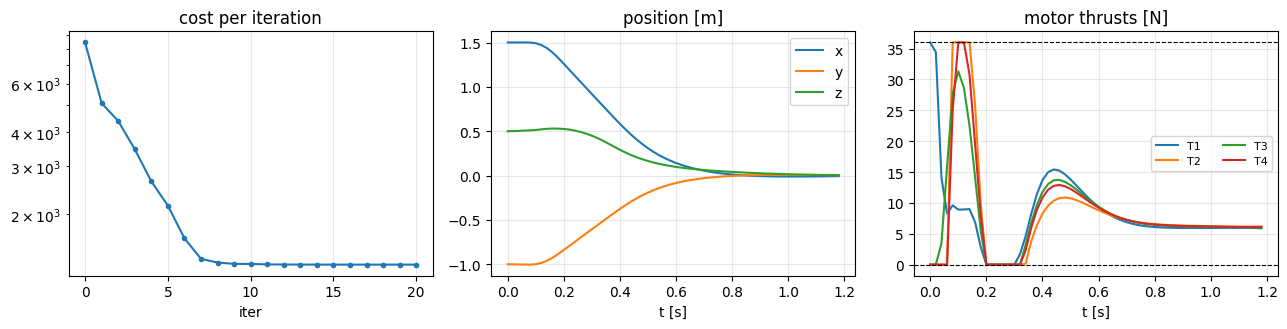

In [66]:
import matplotlib.pyplot as plt

u_ref = np.array([m_val*g_val/4.0]*4)                         # hover thrust per rotor
ref   = make_ref([0,0,0], [1,0,0,0], [0,0,0], [0,0,0], u_ref)

x0 = normalize_quat(np.array([1.5,-1.0,0.5, 1,0.10,0.05,0, 0,0,0, 0.2,0,0], float))
xs, us, hist = ilqr(x0, ref, N=60, iters=60)
U = np.array(us); X = np.array(xs)

print(f"cost {hist[0]:.1f} -> {hist[-1]:.1f} in {len(hist)-1} iterations")
print(f"final position error = {np.linalg.norm(X[-1,0:3]):.4f} m")
print(f"controls span [{U.min():.3f}, {U.max():.3f}] N   (box [{T_MIN}, {T_MAX}])")
assert U.min() >= T_MIN-1e-9 and U.max() <= T_MAX+1e-9
assert all(hist[i+1] <= hist[i]+1e-9 for i in range(len(hist)-1)), "cost not monotone"

t = np.arange(len(us))*DT_MPC
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].semilogy(hist, '-o', ms=3); ax[0].set_title("cost per iteration"); ax[0].set_xlabel("iter"); ax[0].grid(alpha=.3)
for i in range(3): ax[1].plot(t, X[:-1, i], label="xyz"[i])
ax[1].set_title("position [m]"); ax[1].set_xlabel("t [s]"); ax[1].legend(); ax[1].grid(alpha=.3)
for i in range(4): ax[2].plot(t, U[:, i], label=f"T{i+1}")
ax[2].axhline(T_MAX, ls='--', c='k', lw=.8); ax[2].axhline(T_MIN, ls='--', c='k', lw=.8)
ax[2].set_title("motor thrusts [N]"); ax[2].set_xlabel("t [s]"); ax[2].legend(ncol=2, fontsize=8); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

### 5.6 Constraints that bite — tighten the actuator bound

To see the control-limited part earn its name, re-solve an aggressive far-start
with a deliberately tight upper thrust. Several motors ride the bound for a stretch
— the QP keeps every command feasible while the still-free motors do the steering,
and the solve still converges.

cost 25344.0 -> 8625.9, saturated samples 178/320, final pos err 0.0390 m


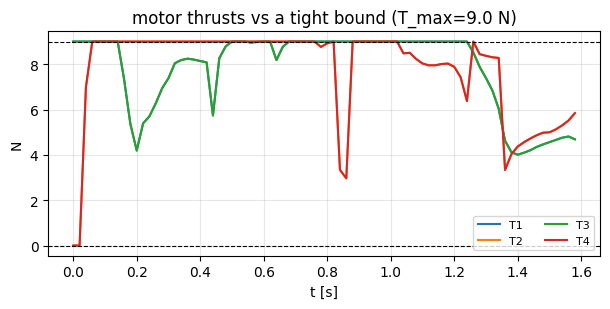

In [67]:
T_MAX_saved = T_MAX
T_MAX = 9.0                                  # tight bound to force saturation
x0b = normalize_quat(np.array([4.0,0,0, 1,0,0,0, 0,0,0, 0,0,0], float))
xsb, usb, histb = ilqr(x0b, ref, N=80, iters=80)
Ub = np.array(usb)
n_sat = int(np.sum((Ub >= T_MAX-1e-6) | (Ub <= T_MIN+1e-6)))
print(f"cost {histb[0]:.1f} -> {histb[-1]:.1f}, saturated samples {n_sat}/{Ub.size}, "
      f"final pos err {np.linalg.norm(np.array(xsb)[-1,0:3]):.4f} m")
assert Ub.min() >= T_MIN-1e-9 and Ub.max() <= T_MAX+1e-9, "box violated"

tb = np.arange(len(usb))*DT_MPC
plt.figure(figsize=(6.2, 3.2))
for i in range(4): plt.plot(tb, Ub[:, i], label=f"T{i+1}")
plt.axhline(T_MAX, ls='--', c='k', lw=.8); plt.axhline(T_MIN, ls='--', c='k', lw=.8)
plt.title(f"motor thrusts vs a tight bound (T_max={T_MAX} N)")
plt.xlabel("t [s]"); plt.ylabel("N"); plt.legend(ncol=2, fontsize=8); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()
T_MAX = T_MAX_saved                          # restore the physical bound

### 5.7 Tracking an aggressive trajectory into hard saturation

The solver now takes a **per-stage reference** `refs[k]`, so we can hand it a real
trajectory instead of a single setpoint. Here the reference makes a fast
6 m + 4 m lateral and 3 m climb concentrated in the **middle third** of the horizon
(a `smootherstep`), and we deliberately tighten the thrust bound to
$T_\mathrm{max}=10$ N — barely above the $mg/4\approx5.9$ N hover thrust.

The demanded acceleration peaks mid-flight, so the motors slam into the bound
right there: the box-QP keeps every command feasible, the vehicle **cuts the
corner** because it physically cannot follow, and the plots show exactly where
and how the saturation happens — motor commands, the tracked 3-D path, and the
per-axis position with the saturated window shaded.

In [68]:
def smootherstep(a):     # 6a^5 - 15a^4 + 10a^3 (C2, flat ends)
    u = np.clip(a, 0.0, 1.0); return u**3*(10 - 15*u + 6*u**2)
def smootherstep_d(a):
    u = np.clip(a, 0.0, 1.0); return np.where((a >= 0) & (a <= 1), 30*u**2*(1 - u)**2, 0.0)

N_tr  = 120                                  # 2.4 s horizon at 50 Hz
t_tr  = np.arange(N_tr + 1)*DT_MPC
T_end = N_tr*DT_MPC
f0, f1 = 0.35, 0.65                          # transition = middle third of the horizon
phase  = (t_tr/T_end - f0)/(f1 - f0)
s      = smootherstep(phase)
s_d    = smootherstep_d(phase)/((f1 - f0)*T_end)

P0 = np.array([0.0, 0.0, 0.0]); P1 = np.array([6.0, 4.0, 3.0])
p_ref = P0 + np.outer(s,   P1 - P0)          # (N_tr+1, 3) position reference
v_ref = np.outer(s_d, P1 - P0)               # its exact derivative (velocity reference)
refs  = [make_ref(p_ref[k], [1,0,0,0], v_ref[k], [0,0,0], u_ref) for k in range(N_tr + 1)]

T_MAX_saved = T_MAX
T_MAX = 10.0                                 # tight bound -> hard mid-trajectory saturation
x0 = normalize_quat(np.array([0,0,0, 1,0,0,0, 0,0,0, 0,0,0], float))
xs, us, hist = ilqr(x0, refs, N=N_tr, iters=120)
X = np.array(xs); U = np.array(us)

sat = (U >= T_MAX-1e-6) | (U <= T_MIN+1e-6)  # (N_tr, 4) boolean saturation mask
n_sat = sat.sum(axis=1)                       # motors at a bound per step
track_err = np.linalg.norm(X[:, 0:3] - p_ref, axis=1)
print(f"cost {hist[0]:.0f} -> {hist[-1]:.0f} in {len(hist)-1} iters")
print(f"peak simultaneous saturated motors: {n_sat.max()} / 4")
print(f"steps with >=1 motor saturated: {int((n_sat>0).sum())} / {N_tr}")
print(f"max tracking error: {track_err.max():.3f} m   (corner is cut under saturation)")
assert U.min() >= T_MIN-1e-9 and U.max() <= T_MAX+1e-9, "box violated"
T_MAX = T_MAX_saved

cost 72863 -> 2613 in 120 iters
peak simultaneous saturated motors: 4 / 4
steps with >=1 motor saturated: 94 / 120
max tracking error: 1.699 m   (corner is cut under saturation)


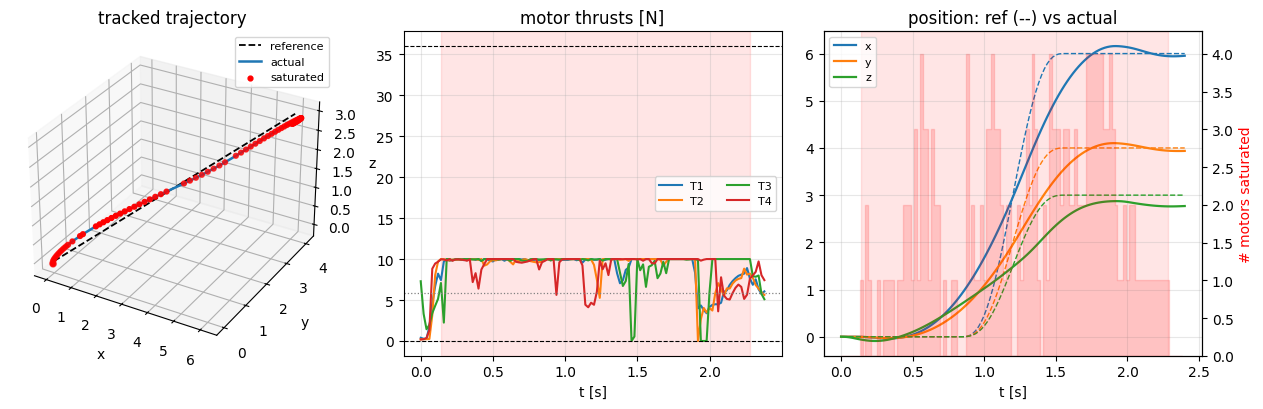

In [69]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
sat_any = n_sat > 0
t_u = t_tr[:-1]
win = t_u[sat_any]
span = (win.min(), win.max()) if sat_any.any() else None

fig = plt.figure(figsize=(13, 4.2))
# (a) 3-D tracked path
ax0 = fig.add_subplot(1, 3, 1, projection='3d')
ax0.plot(p_ref[:,0], p_ref[:,1], p_ref[:,2], 'k--', lw=1.3, label='reference')
ax0.plot(X[:,0], X[:,1], X[:,2], 'C0', lw=1.8, label='actual')
sat_pts = X[:-1][sat_any]
if len(sat_pts): ax0.scatter(sat_pts[:,0], sat_pts[:,1], sat_pts[:,2], c='r', s=12, label='saturated')
ax0.set_title('tracked trajectory'); ax0.set_xlabel('x'); ax0.set_ylabel('y'); ax0.set_zlabel('z')
ax0.legend(fontsize=8)
# (b) motor thrusts
ax1 = fig.add_subplot(1, 3, 2)
for i in range(4): ax1.plot(t_u, U[:,i], label=f'T{i+1}')
ax1.axhline(T_MAX, ls='--', c='k', lw=.8); ax1.axhline(T_MIN, ls='--', c='k', lw=.8)
ax1.axhline(m_val*g_val/4, ls=':', c='gray', lw=.9)
if span: ax1.axvspan(*span, color='r', alpha=.10)
ax1.set_title('motor thrusts [N]'); ax1.set_xlabel('t [s]'); ax1.legend(ncol=2, fontsize=8); ax1.grid(alpha=.3)
# (c) position tracking + saturation count
ax2 = fig.add_subplot(1, 3, 3)
for i,cl in enumerate('xyz'):
    ax2.plot(t_tr, p_ref[:,i], '--', c=f'C{i}', lw=1); ax2.plot(t_tr, X[:,i], c=f'C{i}', lw=1.6, label=cl)
if span: ax2.axvspan(*span, color='r', alpha=.10)
ax2b = ax2.twinx(); ax2b.fill_between(t_u, n_sat, step='mid', color='r', alpha=.15)
ax2b.set_ylabel('# motors saturated', color='r'); ax2b.set_ylim(0, 4.3)
ax2.set_title('position: ref (--) vs actual'); ax2.set_xlabel('t [s]'); ax2.legend(fontsize=8); ax2.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6. Closed loop — receding horizon

Everything so far solved **one** open-loop problem from a fixed start. A real MPC
runs *receding horizon*: each control tick it measures the state, solves the
horizon problem, applies **only the first command** $u_0$, slides the window one
step, and repeats. Two properties make that worthwhile:

- **Feedback by re-planning.** Re-solving from the *measured* state rejects
  disturbances and model error the original plan never saw.
- **Warm starting.** The previous solution, shifted one step ($u_{1:N}$ then a
  repeat of the last command), is an excellent initial guess, so a few iLQR
  iterations replace a cold solve.

To show what "re-planning" actually buys — beyond merely *having* feedback — we
race three controllers built from the **same** trajectory optimisation, on the
same reference and the same gust:

| | applies | rejects disturbance? | re-plans? |
|---|---|---|---|
| **(a) feedforward** | the planned $u_t$ only | no | no |
| **(b) trajectory-LQR** | $u_t + K_t(x-x^{\text{plan}}_t)$ from one solve | yes (small) | no |
| **(c) MPC** | re-solves every tick from $x$ | yes | yes |

(b) is the honest baseline: it is exactly the tracking controller you get from a
*single* iLQR solve — feedforward plus the solver's own time-varying feedback
gains $K_t$. Comparing (c) against (b) isolates the value of *re-optimising*
(not of feedback) — and part of the lesson is how small that margin is when the
disturbance is smooth.

### 6.1 Reference, gust, and the four controllers

A feasible fast dash (2.5 m + 1.5 m lateral, 1 m climb) so all three track well in
nominal conditions; a lateral velocity **gust** kicks the plant mid-run. `F_d`
advances the true plant; the gust is injected as a state kick the planners never
model. `plan_once` produces the nominal $x^{\text{plan}}_t,u_t$ and the feedback
gains $K_t$ that (a) and (b) reuse without re-solving.

In [70]:
SIM, N_h = 70, 25
tot = SIM + N_h + 1
tg  = np.arange(tot)*DT_MPC; T_move = SIM*DT_MPC
ph  = (tg/T_move - 0.15)/(0.80 - 0.15)
spr = smootherstep(ph); spd = smootherstep_d(ph)/((0.80-0.15)*T_move)
Pa, Pb = np.array([0,0,0.]), np.array([2.5, 1.5, 1.0])
p_ref = Pa + np.outer(spr, Pb - Pa)
v_ref = np.outer(spd, Pb - Pa)
ref_traj = np.array([make_ref(p_ref[k], [1,0,0,0], v_ref[k], [0,0,0], u_ref) for k in range(tot)])

G0, G1 = 32, 44                                          # gust window (ticks)
def gust(t):
    g = np.zeros(13)
    if G0 <= t < G1: g[8] = -0.18                        # lateral velocity kick [m/s per step]
    return g
x0 = normalize_quat(np.array([0,0,0, 1,0,0,0, 0,0,0, 0,0,0], float))

def plan_once():                                         # one full-horizon solve -> plan + gains
    xs, us, _ = ilqr(x0, ref_traj[:SIM+1], SIM, iters=80)
    _, Kg = backward_pass(xs, us, ref_traj[:SIM+1], 1e-6)
    return xs, us, Kg

def sim_apply(policy):                                   # roll the true plant under a feedback policy
    x = x0.copy(); X = [x]
    for t in range(SIM):
        u = np.clip(policy(t, x), T_MIN, T_MAX)
        x = normalize_quat(F_d(x, u) + gust(t)); X.append(x)
    return np.array(X)

def mpc_run(sim_steps=SIM, warm=True):                   # (c) receding horizon
    x = x0.copy(); X = [x]; iters = []; us = [u_ref.copy() for _ in range(N_h)]
    for t in range(sim_steps):
        _, us_sol, hist = ilqr(x, ref_traj[t:t+N_h+1], N_h,
                               iters=8 if warm else 60, us_init=us if warm else None)
        iters.append(len(hist)-1)
        x = normalize_quat(F_d(x, np.clip(us_sol[0], T_MIN, T_MAX)) + gust(t)); X.append(x)
        us = us_sol[1:] + [us_sol[-1]]
    return np.array(X), np.array(iters)

In [71]:
xs_p, us_p, Kg_p = plan_once()
Xa = sim_apply(lambda t, x: us_p[t])                              # (a) feedforward
Xb = sim_apply(lambda t, x: us_p[t] + Kg_p[t] @ (x - xs_p[t]))    # (b) trajectory-LQR
Xc, it_c = mpc_run()                                             # (c) MPC (warm)
_,  it_cold = mpc_run(sim_steps=15, warm=False)                  # cold, short, for the iter count

def track_err(X): return np.linalg.norm(X[:SIM+1, 0:3] - p_ref[:SIM+1], axis=1)
ea, eb, ec = track_err(Xa), track_err(Xb), track_err(Xc)
for name, e in [("(a) feedforward ", ea), ("(b) trajectory-LQR", eb), ("(c) MPC         ", ec)]:
    print(f"{name}: RMS {np.sqrt((e**2).mean()):.3f} m, peak {e.max():.3f} m, post-gust settle {e[-1]:.3f} m")
print(f"warm start: {it_c.mean():.1f} iters/tick (peak {it_c.max()})  vs  cold {it_cold.mean():.1f}")

(a) feedforward : RMS 0.534 m, peak 1.304 m, post-gust settle 1.304 m
(b) trajectory-LQR: RMS 0.201 m, peak 0.412 m, post-gust settle 0.040 m
(c) MPC         : RMS 0.188 m, peak 0.388 m, post-gust settle 0.079 m
warm start: 4.1 iters/tick (peak 8)  vs  cold 6.8


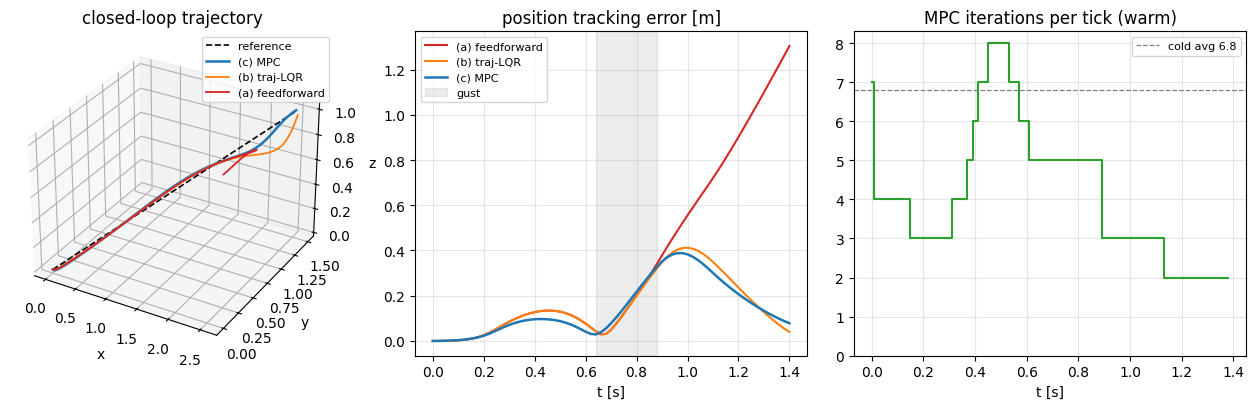

In [72]:
tu = np.arange(SIM)*DT_MPC; tf = np.arange(SIM+1)*DT_MPC
fig = plt.figure(figsize=(13, 4.2))
ax0 = fig.add_subplot(1, 3, 1, projection='3d')
ax0.plot(p_ref[:SIM+1,0], p_ref[:SIM+1,1], p_ref[:SIM+1,2], 'k--', lw=1.2, label='reference')
ax0.plot(Xc[:,0], Xc[:,1], Xc[:,2], 'C0', lw=1.8, label='(c) MPC')
ax0.plot(Xb[:,0], Xb[:,1], Xb[:,2], 'C1', lw=1.3, label='(b) traj-LQR')
ax0.plot(Xa[:,0], Xa[:,1], Xa[:,2], 'C3', lw=1.3, label='(a) feedforward')
ax0.set_title('closed-loop trajectory'); ax0.set_xlabel('x'); ax0.set_ylabel('y'); ax0.set_zlabel('z'); ax0.legend(fontsize=8)
ax1 = fig.add_subplot(1, 3, 2)
ax1.plot(tf, ea, 'C3', label='(a) feedforward'); ax1.plot(tf, eb, 'C1', label='(b) traj-LQR'); ax1.plot(tf, ec, 'C0', lw=1.8, label='(c) MPC')
ax1.axvspan(G0*DT_MPC, G1*DT_MPC, color='gray', alpha=.15, label='gust')
ax1.set_title('position tracking error [m]'); ax1.set_xlabel('t [s]'); ax1.legend(fontsize=8); ax1.grid(alpha=.3)
ax2 = fig.add_subplot(1, 3, 3)
ax2.plot(tu, it_c, 'C2', drawstyle='steps-mid'); ax2.axhline(it_cold.mean(), ls='--', c='gray', lw=.9, label=f'cold avg {it_cold.mean():.1f}')
ax2.set_title('MPC iterations per tick (warm)'); ax2.set_xlabel('t [s]'); ax2.set_ylim(bottom=0); ax2.legend(fontsize=8); ax2.grid(alpha=.3)
plt.tight_layout(); plt.show()

The gust hits all three about equally (similar peak); what separates them is what
happens next. **Feedback is decisive**: pure feedforward (a) never corrects and
drifts away, settling more than a metre off, while both feedback controllers stay
within a few tens of centimetres. Between (b) and (c) the result is closer and more
honest than a slogan — MPC rides the nonlinear excursion with a slightly lower peak
and RMS by re-planning each tick, while the trajectory-LQR, whose gains come from a
*full-horizon* solve, settles marginally tighter. The real takeaway: for a smooth
disturbance a well-built trajectory-LQR rivals MPC; MPC's structural edge is
previewing an upcoming actuator limit and re-optimising when a disturbance changes
*which* constraints bind — the regime of §5.6-5.7 — not a single mild gust.
Meanwhile warm starting holds the re-solve to a few iterations per tick, the
practical line between running in real time and not.

### 6.3 Leaving the tube — where re-planning is decisive

The gust above kept the state in a *tube* around the nominal, so (b) and (c)
tracked almost identically: a frozen feedback gain is enough there. The honest
place MPC pulls decisively ahead is when the state leaves that tube.

Recall what (b) actually is: its gains $K_t$ are linearised about the **nominal**
$x^{\text{plan}}_t$, so the correction $K_t(x-x^{\text{plan}}_t)$ is a *first-order*
model — valid only for small $x-x^{\text{plan}}_t$. Here we make the nominal a plain
hover (so $K_t$ is essentially the constant hover gain — the same controller as the
FF+LQR notebook) and start the vehicle **far from it**: rolled past vertical, with a
body rate and a sideways velocity. Below ~90° both recover. Past ~90° the
linearisation is simply wrong: (b) commands a correction computed about upright and
**flies away**, while (c) re-linearises and re-optimises from the *actual* attitude
and rights itself.

This is also the honest answer to "is the MPC guaranteed to stabilise?" — **no
certificate**. It recovers across the envelope below, but the residual left at
120° versus the clean recovery at 160° is the fingerprint of a *local* optimiser
with a heuristic terminal cost and a short horizon: it works here, it is not
proven to.

In [73]:
SIM_s, N_s = 70, 25
ref_hover = make_ref([0,0,0], [1,0,0,0], [0,0,0], [0,0,0], u_ref)
ref_stab  = np.tile(ref_hover, (SIM_s + N_s + 1, 1))
x_hover   = normalize_quat(np.array([0,0,0, 1,0,0,0, 0,0,0, 0,0,0], float))

# (b) TVLQR: gains sewn onto the hover nominal -> ~ the constant hover gain of the FF+LQR notebook
xs_nom, us_nom, _ = ilqr(x_hover, ref_stab[:SIM_s+1], SIM_s, iters=60)
_, Kg_nom = backward_pass(xs_nom, us_nom, ref_stab[:SIM_s+1], 1e-6)

def q_roll(phi):  return [np.cos(phi/2), np.sin(phi/2), 0.0, 0.0]
def att_deg(x):   return np.degrees(2*np.arccos(np.clip(abs(x[3]), 0.0, 1.0)))

def tvlqr_from(x0):                                   # (b) frozen gains, no re-solve
    x = x0.copy(); X = [x]
    for t in range(SIM_s):
        du = Kg_nom[t] @ (x - xs_nom[t])
        x = normalize_quat(F_d(x, np.clip(us_nom[t] + du, T_MIN, T_MAX))); X.append(x)
    return np.array(X)

def mpc_from(x0):                                     # (c) re-solve each tick from the true state
    x = x0.copy(); X = [x]; us = [u_ref.copy() for _ in range(N_s)]
    for t in range(SIM_s):
        _, us_sol, _ = ilqr(x, ref_stab[t:t+N_s+1], N_s, iters=8, us_init=us)
        x = normalize_quat(F_d(x, np.clip(us_sol[0], T_MIN, T_MAX))); X.append(x)
        us = us_sol[1:] + [us_sol[-1]]
    return np.array(X)

In [74]:
runs = {}
print("initial roll        TVLQR  final(att / dist)        MPC  final(att / dist)")
for phi_deg, wx, vy in [(45,1.0,-0.8), (80,2.0,-1.5), (120,2.5,-1.8), (160,3.0,-2.0)]:
    x0 = normalize_quat(np.array([0,0,0, *q_roll(np.radians(phi_deg)), 0,vy,0, wx,0,0], float))
    Xb, Xc = tvlqr_from(x0), mpc_from(x0)
    runs[phi_deg] = (Xb, Xc)
    print(f"  {phi_deg:3d} deg        {att_deg(Xb[-1]):5.1f} deg / {np.linalg.norm(Xb[-1,0:3]):6.2f} m"
          f"          {att_deg(Xc[-1]):5.1f} deg / {np.linalg.norm(Xc[-1,0:3]):6.2f} m")

initial roll        TVLQR  final(att / dist)        MPC  final(att / dist)
   45 deg          0.1 deg /   0.00 m            0.0 deg /   0.00 m
   80 deg          1.2 deg /   0.01 m            0.2 deg /   0.01 m
  120 deg        113.6 deg /  14.22 m           36.3 deg /   0.15 m
  160 deg         99.0 deg /  13.98 m            0.5 deg /   0.00 m


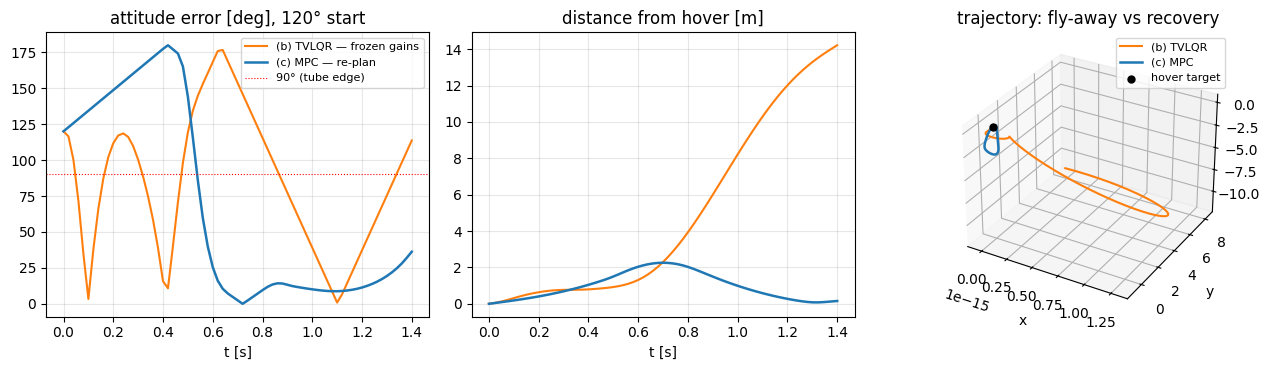

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/diego/Documents/University/lab/Controlled Descent Simulator/modeling/venv/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/Users/diego/Documents/University/lab/Controlled Descent Simulator/modeling/venv/lib/python3.14/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/Users/diego/Documents/University/lab/Controlled Descent Simulator/modeling/venv/lib/python3.14/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/diego/Documents/University/lab/Controlled Descent 

: 

In [ ]:
Xb, Xc = runs[120]; th = np.arange(SIM_s+1)*DT_MPC
fig = plt.figure(figsize=(13, 3.8))
ax0 = fig.add_subplot(1, 3, 1)
ax0.plot(th, [att_deg(x) for x in Xb], 'C1', label='(b) TVLQR — frozen gains')
ax0.plot(th, [att_deg(x) for x in Xc], 'C0', lw=1.8, label='(c) MPC — re-plan')
ax0.axhline(90, ls=':', c='r', lw=.8, label='90° (tube edge)')
ax0.set_title('attitude error [deg], 120° start'); ax0.set_xlabel('t [s]'); ax0.legend(fontsize=8); ax0.grid(alpha=.3)
ax1 = fig.add_subplot(1, 3, 2)
ax1.plot(th, np.linalg.norm(Xb[:,0:3], axis=1), 'C1'); ax1.plot(th, np.linalg.norm(Xc[:,0:3], axis=1), 'C0', lw=1.8)
ax1.set_title('distance from hover [m]'); ax1.set_xlabel('t [s]'); ax1.grid(alpha=.3)
ax2 = fig.add_subplot(1, 3, 3, projection='3d')
ax2.plot(Xb[:,0], Xb[:,1], Xb[:,2], 'C1', label='(b) TVLQR')
ax2.plot(Xc[:,0], Xc[:,1], Xc[:,2], 'C0', lw=1.8, label='(c) MPC')
ax2.scatter([0],[0],[0], c='k', s=25, label='hover target')
ax2.set_title('trajectory: fly-away vs recovery'); ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. What we have, and what's left

A complete nonlinear MPC for the quadrotor, every piece validated and reused:

- **prediction** $F_d,\;A_k,B_k$ (§2–§3), **cost** with Gauss–Newton Hessians (§4),
- **iLQR / control-limited DDP** with a box-QP and line search (§5), shown holding
  a binding actuator bound, and
- a **receding-horizon** loop with warm starting and disturbance rejection (§6).

**Left for the runtime:**

- *C++ export* — emit $f,f_x,f_u$ through the codegen (the `*_codegen.py` path) and
  port `box_qp`, `backward_pass`, `forward_pass` into the hand-written controller,
  deciding where the warm-start trajectory lives across ticks (the solver is
  stateful, unlike the stateless LQR `ExecuteControl`).